# 04 — Griddata and weighted correlation

Project mark levels onto the landscape grid, smooth with masked median/Gaussian filters, then compute **signal-weighted** correlation between `acet` and `meth` on the same bins.

Requires landscape coordinates from notebook 02 (`demos/data/demo_landscape.h5ad`).


In [1]:
from pathlib import Path
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import sparscit as sc

sc.set_defaults(n_jobs=-1, figsize=(6, 5))

land = Path("../epigenetic_landscape_analysis_notebooks/demos/data") / "demo_landscape.h5ad"
if not land.is_file():
    raise FileNotFoundError("Run notebook 02 first to write demos/data/demo_landscape.h5ad")
adata = ad.read_h5ad(land)
assert "X_landscape" in adata.obsm
print(adata.shape)


(4970, 21925)


In [2]:
# Small feature panel for speed
var = np.asarray(
    adata.layers["acet"].power(2).mean(0) - np.square(adata.layers["acet"].mean(0))
).ravel()
top = np.argsort(var)[-40:]
sub = adata[:, top].copy()
sub.obsm["X_landscape"] = adata.obsm["X_landscape"].copy()


In [3]:
sc.adv.make_grid(sub, resolution=(80, 80))
for name in ("acet", "meth"):
    lc = sc.tl.make_layer_config(
        name,
        normalize_with_obs_counts=True,
        log_transform=True,
        feature_names=sub.var_names.to_numpy(),
    )
    sc.adv.griddata_numerical(sub, lc, min_cells=3, use_cached_mask=False)
    # median + gaussian; writes t_<name> in [0,1]-scaled grid space
    sc.adv.griddata_apply_transformations(
        sub,
        name,
        gauss_kernel=(1.0, 1.0),
        median_filter_size=(3, 3),
        winsor_qs_high=0.99,
        all_feature_q_norm=0.5,
        max_up=5.0,
    )
print("griddata keys:", list(sub.uns["griddata"].keys()))


/home/aleksander-work/Dokument/work11/scit-package/src/sparscit/tools/_layers.py:202: RuntimeWarning: divide by zero encountered in divide
  _X = (diags(1 / d) @ _X)


Info: Added Griddata to .uns[acet]
Info: Added Griddata to .uns[t_acet]
Info: Added Griddata to .uns[meth]
Info: Added Griddata to .uns[t_meth]
griddata keys: ['acet', 't_acet', 'meth', 't_meth']


In [4]:
features = sub.var_names.to_numpy()
df = sc.adv.griddata_correlations(
    [sub, sub],
    ["t_acet", "t_meth"],
    features,
    spearman=False,
    signal_weighting=True,
)
print(df.head(10))


shape: (10, 2)
┌───────────┬─────────────────────────┐
│ res       ┆ var_name                │
│ ---       ┆ ---                     │
│ f32       ┆ str                     │
╞═══════════╪═════════════════════════╡
│ -0.973312 ┆ chr4:485000-490000      │
│ NaN       ┆ chr4:875000-880000      │
│ -0.931688 ┆ chr4:1060000-1065000    │
│ -0.668821 ┆ chr4:1025000-1030000    │
│ -0.90619  ┆ chr2R:9550000-9555000   │
│ -0.709828 ┆ chr2R:1070000-1075000   │
│ -0.69836  ┆ chr2R:6220000-6225000   │
│ -0.880052 ┆ chr2R:20110000-20115000 │
│ -0.893316 ┆ chr3R:5110000-5115000   │
│ -0.848419 ┆ chr2L:21865000-21870000 │
└───────────┴─────────────────────────┘


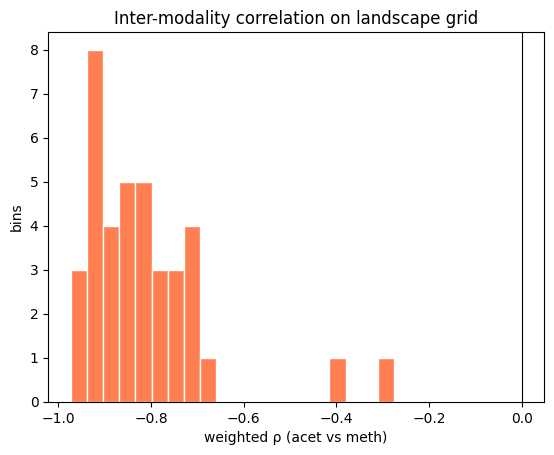

shape: (5, 2)
┌───────────┬─────────────────────────┐
│ res       ┆ var_name                │
│ ---       ┆ ---                     │
│ f32       ┆ str                     │
╞═══════════╪═════════════════════════╡
│ -0.973312 ┆ chr4:485000-490000      │
│ -0.959318 ┆ chr2L:22130000-22135000 │
│ -0.959021 ┆ chr3R:16250000-16255000 │
│ -0.938265 ┆ chr2L:2750000-2755000   │
│ -0.93358  ┆ chr4:505000-510000      │
└───────────┴─────────────────────────┘
shape: (5, 2)
┌───────────┬─────────────────────────┐
│ res       ┆ var_name                │
│ ---       ┆ ---                     │
│ f32       ┆ str                     │
╞═══════════╪═════════════════════════╡
│ NaN       ┆ chr4:875000-880000      │
│ NaN       ┆ chr4:190000-195000      │
│ -0.275072 ┆ chr2R:5415000-5420000   │
│ -0.386759 ┆ chr2R:21700000-21705000 │
│ -0.668821 ┆ chr4:1025000-1030000    │
└───────────┴─────────────────────────┘


In [5]:
# Drop NaNs (flat grids) and plot
pdf = df.drop_nulls()
plt.hist(pdf["res"].to_numpy(), bins=20, color="coral", edgecolor="white")
plt.xlabel("weighted ρ (acet vs meth)"); plt.ylabel("bins")
plt.title("Inter-modality correlation on landscape grid")
plt.axvline(0, color="k", lw=0.8)
plt.show()
print(pdf.sort("res").head(5))
print(pdf.sort("res", descending=True).head(5))
